In [38]:
import numpy as np
import pandas as pd
import warnings
from scipy import stats
warnings.simplefilter(action='ignore', category=FutureWarning)




# Question 1

In [39]:
import preprocess_assgn4
preprocess_assgn4.preprocess()

# Question 2

In [40]:
train_df = pd.read_csv('data/trainingSet.csv')
test_df = pd.read_csv('data/testSet.csv')

In [41]:
# Calculate gini index
def gini_index(df, colA, v):
    labels = np.unique(df['decision'])
    gini = 0
    S_A = len(df[df[colA] == v])
    for l in labels:
        p_x = len(df[(df['decision'] == l) & (df[colA] == v)]) /S_A
        gini = gini + p_x**2
    
    return 1-gini, S_A

In [42]:
class TreeNode:
    def __init__(self, type_node):
        self.attribute = None
        self.type = type_node
        self.split_df = None
        self.left = None
        self.right = None

In [43]:
# Define a function to build the decision tree recursively
def build_tree(df, depth, max_depth=8, min_samples=50, forest=False):
    if len(df) == 0:
        return
    
    labels = np.unique(df['decision'])
    if len(labels) == 1:
        leaf_node = TreeNode(type_node='leaf')
        leaf_node.left = labels[0]
        leaf_node.right = labels[0]
        leaf_node.split_df = df
        return leaf_node
    
    num_samples_per_class = [np.sum(df['decision'] == l) for l in labels]
    predicted_class = np.argmax(num_samples_per_class)
    
    if (depth >= max_depth) or (len(df) < min_samples):
        leaf_node = TreeNode(type_node='leaf')
        leaf_node.left = predicted_class
        leaf_node.right = predicted_class
        leaf_node.split_df = df
        return leaf_node
    
    # Calculate gini gain for each attribute
    gini_gain_dict = {}
    gini_S =  1 - np.sum([(num_samples_class_l/len(df))**2 for num_samples_class_l in num_samples_per_class])
    S = len(df)
    col_list = df.columns[:-1]
    
    # Downsample by a sqrt(p)
    if forest:
        p = len(col_list)
        num_downsample_attributes = int(np.sqrt(p))
        col_list = np.random.choice(col_list, num_downsample_attributes, replace=False)
    
    for col in col_list:
        values = np.unique(df[col])
        gini_gain = gini_S
        for v in values:
            gini_SA, S_A = gini_index(df, col, v)
            gini_gain = gini_gain - (S_A/S)*gini_SA
        gini_gain_dict[col] = gini_gain
    
    # Find atrribute with the maximum gini gain
    if len(gini_gain_dict) == 0:
        leaf_node = TreeNode(type_node='leaf')
        leaf_node.left = predicted_class
        leaf_node.right = predicted_class
        leaf_node.split_df = df
        return leaf_node
    chosen_attribute = max(gini_gain_dict, key=gini_gain_dict.get)
    
    internal_node = TreeNode(type_node='internal')
    internal_node.split_df = df
    internal_node.attribute = chosen_attribute
    
    new_split_left = df[df[chosen_attribute] == 0]
    if forest:
        new_split_left = new_split_left.drop(chosen_attribute, axis=1)
    new_split_right = df[df[chosen_attribute] == 1]
    if forest:
        new_split_right = new_split_right.drop(chosen_attribute, axis=1)

    
    
    internal_node.left = build_tree(new_split_left, depth + 1, max_depth=max_depth, min_samples=min_samples, forest=forest)
    internal_node.right = build_tree(new_split_right, depth + 1, max_depth=max_depth, min_samples=min_samples, forest=forest)
        
    return internal_node

# Build the decision tree


In [44]:
def print_tree(node, spacing=""):
    if node is None:
        return

    # Print the current node's details
    if node.type == 'internal':
        print(spacing + f"Feature {node.attribute}")
    elif node.type == 'leaf':
        print(spacing + f"Label {node.left} == {node.right}")
        return

    # Recursively print the left and right subtrees
    print_tree(node.left, spacing + "l|-- ")
    print_tree(node.right, spacing + "r|-- ")

In [45]:
def predict_tree(node, x):
    if node.type == 'leaf':
        return node.left
    if x[node.attribute] == 0:
        return predict_tree(node.left, x)
    else:
        return predict_tree(node.right, x)

In [46]:
# Create pseudosamples from the dataset with replacement
def pseudosamples(df):    
    return df.sample(frac=1, replace=True)


In [47]:
# Make a prediction with a bag of trees
def accuracy_compute_bagging(bag_trees, df):
    accuracy = 0
    for index in range(len(df)):
        X = df.iloc[index]
        # remove the ground truth from the input
        ground_truth = X['decision']
        predictions = [predict_tree(tree, X) for tree in bag_trees]
        prediction = max(set(predictions), key=predictions.count)
        if prediction == ground_truth:
            accuracy += 1
    return (accuracy/len(df))
 

In [48]:
def accuracy_compute_decision_tree(tree, df):
    accuracy = 0
    for index in range(len(df)):
        X = df.iloc[index]
        # remove the ground truth from the input
        ground_truth = X['decision']
        prediction = predict_tree(tree, X)
        if prediction == ground_truth:
            accuracy += 1
    return(accuracy/len(df))

In [49]:
def train_bagging(train_df, n_trees, forest, max_depth, min_samples):
    bag_trees = list()
    for i in range(n_trees):
        pseudo_train_df = pseudosamples(train_df)
        if forest:
            tree_i = build_tree(pseudo_train_df, 0, max_depth, min_samples, forest)
        else:
            tree_i = build_tree(pseudo_train_df, 0, max_depth, min_samples, forest)
        bag_trees.append(tree_i)
    
    return bag_trees

In [50]:
tree = build_tree(train_df, 0, 8, 50)
print_tree(tree)

Feature like
l|-- Feature attractive_partner
l|-- l|-- Feature intelligence
l|-- l|-- l|-- Feature intelligence_important
l|-- l|-- l|-- l|-- Feature pref_o_attractive
l|-- l|-- l|-- l|-- l|-- Feature pref_o_sincere
l|-- l|-- l|-- l|-- l|-- l|-- Feature concerts
l|-- l|-- l|-- l|-- l|-- l|-- l|-- Label 0 == 0
l|-- l|-- l|-- l|-- l|-- l|-- r|-- Feature clubbing
l|-- l|-- l|-- l|-- l|-- l|-- r|-- l|-- Label 0 == 0
l|-- l|-- l|-- l|-- l|-- l|-- r|-- r|-- Label 0 == 0
l|-- l|-- l|-- l|-- l|-- r|-- Label 0 == 0
l|-- l|-- l|-- l|-- r|-- Label 1 == 1
l|-- l|-- l|-- r|-- Feature concerts
l|-- l|-- l|-- r|-- l|-- Label 1 == 1
l|-- l|-- l|-- r|-- r|-- Label 0 == 0
l|-- l|-- r|-- Feature expected_happy_with_sd_people
l|-- l|-- r|-- l|-- Feature funny_partner
l|-- l|-- r|-- l|-- l|-- Feature sincere_important
l|-- l|-- r|-- l|-- l|-- l|-- Feature music
l|-- l|-- r|-- l|-- l|-- l|-- l|-- Label 0 == 0
l|-- l|-- r|-- l|-- l|-- l|-- r|-- Label 0 == 0
l|-- l|-- r|-- l|-- l|-- r|-- Label 0 == 0
l|-- l|-

In [51]:
def trees(trainingDataFilename='trainingSet.csv', testDataFilename='testSet.csv', modelIdx=1):
    #read data
    train_df = pd.read_csv(trainingDataFilename)
    test_df = pd.read_csv(testDataFilename)
    
    # hyper-parameters to train trees
    max_depth = 8
    min_samples = 50
    
    #nested function
    def decisionTree(trainingSet, testSet):
        # Build the decision tree
        tree = build_tree(trainingSet, 0, max_depth, min_samples)
        train_accuracy = accuracy_compute_decision_tree(tree, trainingSet)
        test_accuracy = accuracy_compute_decision_tree(tree, testSet)
        return train_accuracy, test_accuracy
    
    def bagging(trainingSet, testSet):
        n_trees = 30
        # Build bag of trees
        bag_trees = train_bagging(trainingSet, n_trees, forest=False, max_depth=max_depth, min_samples=min_samples)
        train_accuracy = accuracy_compute_bagging(bag_trees, trainingSet)
        test_accuracy = accuracy_compute_bagging(bag_trees, testSet)
        return train_accuracy, test_accuracy
    
    def randomForests(trainingSet, testSet):
        n_trees = 30
        # Build random forests
        forests = train_bagging(trainingSet, n_trees, forest=True, max_depth=max_depth, min_samples=min_samples)
        train_accuracy = accuracy_compute_bagging(forests, trainingSet)
        test_accuracy = accuracy_compute_bagging(forests, testSet)
        return train_accuracy, test_accuracy
        
    if modelIdx==1:
        train_accuracy, test_accuracy = decisionTree(trainingSet=train_df, testSet=test_df)
        model_name = 'DT'
    elif modelIdx==2:
        train_accuracy, test_accuracy = bagging(trainingSet=train_df, testSet=test_df)
        model_name = 'BT'
    elif modelIdx==3:
        train_accuracy, test_accuracy = randomForests(trainingSet=train_df, testSet=test_df)
        model_name = 'RF'
    else:
        train_accuracy = 0
        test_accuracy = 0
        model_name = ''
    
    print(f'Training Accuracy {model_name}: {train_accuracy:.2f}')
    print(f'Testing Accuracy {model_name}: {test_accuracy:.2f}')


In [52]:
trees(modelIdx=1)

FileNotFoundError: [Errno 2] No such file or directory: 'trainingSet.csv'

In [ ]:
trees('trainingSet.csv','testSet.csv',2)

Training Accuracy BT: 0.80
Testing Accuracy BT: 0.75


In [ ]:
trees('trainingSet.csv','testSet.csv',3)

Training Accuracy RF: 0.77
Testing Accuracy RF: 0.74


# Section 3

In [55]:
shuffled_train_df = train_df.sample(frac=1, replace=False, random_state=18)
sampled_shuffled_train_df = shuffled_train_df.sample(frac=0.5, replace=False, random_state=32)


In [56]:
n_samples = len(sampled_shuffled_train_df)

In [57]:
k_folds = 10
n_fold = n_samples*k_folds/100
d = [3, 5, 7, 9]
#d = [3, 5]
mean_test_accu_DT = []
stderr_test_accu_DT = []
mean_train_accu_DT = []
stderr_train_accu_DT = []
mean_test_accu_BT = []
stderr_test_accu_BT = []
mean_train_accu_BT = []
stderr_train_accu_BT = []
mean_test_accu_RF = []
stderr_test_accu_RF = []
mean_train_accu_RF = []
stderr_train_accu_RF = []
results_list_DT = []
results_list_BT = []
results_list_RF = []
for d_i in d:
    print(d_i)
    test_accu_DT = []
    train_accu_DT = []
    test_accu_BT = []
    train_accu_BT = []
    test_accu_RF = []
    train_accu_RF = []
    for i in range(k_folds):
        # Constructing 
        start = int(i*n_fold)
        end = int((i+1)*n_fold)
        cur_test_df = sampled_shuffled_train_df[start:end]
        cur_train_df = sampled_shuffled_train_df.drop(cur_test_df.index)
        
        # Decision Tree
        cur_tree = build_tree(cur_train_df, 0, max_depth=d_i, min_samples=50, forest=False)
        train_accu_DT.append(accuracy_compute_decision_tree(cur_tree, cur_train_df))
        test_accu_DT.append(accuracy_compute_decision_tree(cur_tree, cur_test_df))
        
        n_trees = 30
        # Build a bag of trees
        bag_trees = train_bagging(cur_train_df, n_trees, forest=False, max_depth=d_i, min_samples=50)
        train_accu_BT.append(accuracy_compute_bagging(bag_trees, cur_train_df))
        test_accu_BT.append(accuracy_compute_bagging(bag_trees, cur_test_df))
        
        # Build a forest
        forests = train_bagging(cur_train_df, n_trees, forest=True, max_depth=d_i, min_samples=50)
        train_accu_RF.append(accuracy_compute_bagging(forests, cur_train_df))
        test_accu_RF.append(accuracy_compute_bagging(forests, cur_test_df))
        
    mean_test_accu_DT.append(np.mean(test_accu_DT))
    stderr_test_accu_DT.append(np.std(test_accu_DT)/np.sqrt(k_folds))
    mean_train_accu_DT.append(np.mean(train_accu_DT))
    stderr_train_accu_DT.append(np.std(train_accu_DT)/np.sqrt(k_folds))
    
    mean_test_accu_BT.append(np.mean(test_accu_BT))
    stderr_test_accu_BT.append(np.std(test_accu_BT)/np.sqrt(k_folds))
    mean_train_accu_BT.append(np.mean(train_accu_BT))
    stderr_train_accu_BT.append(np.std(train_accu_BT)/np.sqrt(k_folds))
    
    mean_test_accu_RF.append(np.mean(test_accu_RF))
    stderr_test_accu_RF.append(np.std(test_accu_RF)/np.sqrt(k_folds))
    mean_train_accu_RF.append(np.mean(train_accu_RF))
    stderr_train_accu_RF.append(np.std(train_accu_RF)/np.sqrt(k_folds))
    
    results_list_DT.append(test_accu_DT)
    results_list_BT.append(test_accu_BT)
    results_list_RF.append(test_accu_RF)



3
5
7
9


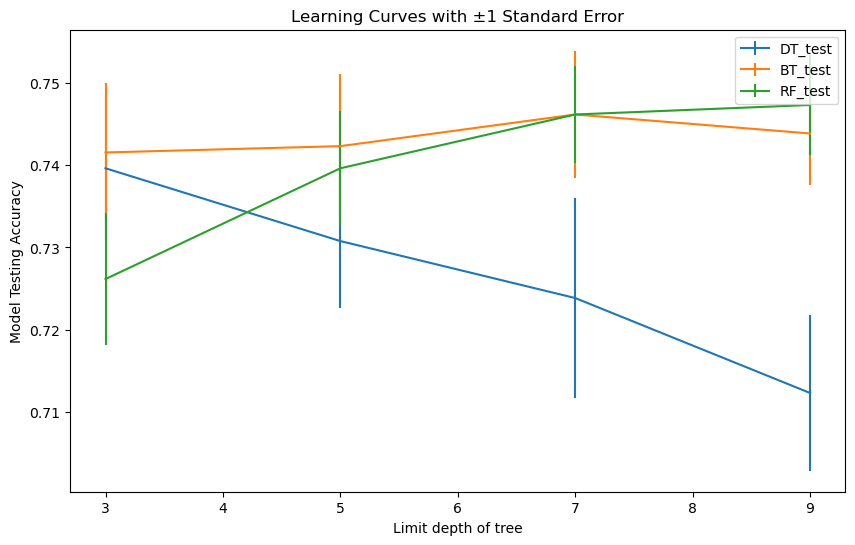

In [58]:
import matplotlib.pyplot as plt
# Plotting
plt.figure(figsize=(10, 6))
plt.errorbar(d, mean_test_accu_DT, yerr=stderr_test_accu_DT, label='DT_test')
#plt.errorbar(d, mean_train_accu_DT, yerr=stderr_train_accu_DT, label='DT_train')
plt.errorbar(d, mean_test_accu_BT, yerr=stderr_test_accu_BT, label='BT_test')
#plt.errorbar(d, mean_train_accu_BT, yerr=stderr_train_accu_BT, label='BT_train')
plt.errorbar(d, mean_test_accu_RF, yerr=stderr_test_accu_RF, label='RF_test')
#plt.errorbar(d, mean_train_accu_RF, yerr=stderr_train_accu_RF, label='RF_train')

plt.xlabel('Limit depth of tree')
plt.ylabel('Model Testing Accuracy')
plt.legend()
plt.title('Learning Curves with ±1 Standard Error')
plt.show()

$H_0$: There is no significant difference in testing accuracy between BT and RF across different limits depth of tree

$H_1$: There is a significant difference in testing accuracy between BT and RF across different limits depth of tree

In [59]:
alpha = 0.05
# Perform a paired t-test
for i, d_i in enumerate(d):
    
    test_accu_BT = results_list_BT[i]
    test_accu_RF = results_list_RF[i]

    t_statistic, p_value = stats.ttest_rel(test_accu_BT, test_accu_RF)


    print(f'depth of tree = {d_i} and significance level alpha = {alpha}')

    if p_value < alpha:
        print(f"Reject the null hypothesis with (p-value = {p_value} < alpha)")
    else:
        print(f"Fail to reject the null hypothesis (p-value = {p_value} >= alpha)")

depth of tree = 3 and significance level alpha = 0.05
Reject the null hypothesis with (p-value = 0.028445926371074088 < alpha)
depth of tree = 5 and significance level alpha = 0.05
Fail to reject the null hypothesis (p-value = 0.5831230675471469 >= alpha)
depth of tree = 7 and significance level alpha = 0.05
Fail to reject the null hypothesis (p-value = 0.9999999999999981 >= alpha)
depth of tree = 9 and significance level alpha = 0.05
Fail to reject the null hypothesis (p-value = 0.3835978783257348 >= alpha)


# Section 4

In [25]:
shuffled_train_df = train_df.sample(frac=1, replace=False, random_state=18)


In [26]:
n_samples = len(shuffled_train_df)

In [27]:
k_folds = 10
n_fold = n_samples*k_folds/100
train_set_list = []
test_set_list = []
for i in range(k_folds):
    # Constructing 
    start = int(i*n_fold)
    end = int((i+1)*n_fold)
    cur_test_df = shuffled_train_df[start:end]
    cur_train_df = shuffled_train_df.drop(cur_test_df.index)
    train_set_list.append(cur_train_df)
    test_set_list.append(cur_test_df)


In [28]:
t_frac_list = [0.05, 0.075, 0.1, 0.15, 0.2]
q4_mean_test_accu_DT = []
q4_stderr_test_accu_DT = []
q4_mean_train_accu_DT = []
q4_stderr_train_accu_DT = []
q4_mean_test_accu_BT = []
q4_stderr_test_accu_BT = []
q4_mean_train_accu_BT = []
q4_stderr_train_accu_BT = []
q4_mean_test_accu_RF = []
q4_stderr_test_accu_RF = []
q4_mean_train_accu_RF = []
q4_stderr_train_accu_RF = []
q4_results_list_DT = []
q4_results_list_BT = []
q4_results_list_RF = []
for t_frac in t_frac_list:
    print(t_frac)
    test_accu_DT = []
    train_accu_DT = []
    test_accu_BT = []
    train_accu_BT = []
    test_accu_RF = []
    train_accu_RF = []
    for i in range(k_folds):
        
        cur_train_df = train_set_list[i].sample(frac=t_frac, replace=False, random_state=32)
        cur_test_df = test_set_list[i]
        
        # Decision Tree
        cur_tree = build_tree(cur_train_df, 0, max_depth=8, min_samples=50, forest=False)
        train_accu_DT.append(accuracy_compute_decision_tree(cur_tree, cur_train_df))
        test_accu_DT.append(accuracy_compute_decision_tree(cur_tree, cur_test_df))
        
        n_trees = 30
        # Build a bag of trees
        bag_trees = train_bagging(cur_train_df, n_trees, forest=False, max_depth=8, min_samples=50)
        train_accu_BT.append(accuracy_compute_bagging(bag_trees, cur_train_df))
        test_accu_BT.append(accuracy_compute_bagging(bag_trees, cur_test_df))
        
        # Build a forest
        forests = train_bagging(cur_train_df, n_trees, forest=True, max_depth=8, min_samples=50)
        train_accu_RF.append(accuracy_compute_bagging(forests, cur_train_df))
        test_accu_RF.append(accuracy_compute_bagging(forests, cur_test_df))
        
    q4_mean_test_accu_DT.append(np.mean(test_accu_DT))
    q4_stderr_test_accu_DT.append(np.std(test_accu_DT)/np.sqrt(k_folds))
    q4_mean_train_accu_DT.append(np.mean(train_accu_DT))
    q4_stderr_train_accu_DT.append(np.std(train_accu_DT)/np.sqrt(k_folds))
    
    q4_mean_test_accu_BT.append(np.mean(test_accu_BT))
    q4_stderr_test_accu_BT.append(np.std(test_accu_BT)/np.sqrt(k_folds))
    q4_mean_train_accu_BT.append(np.mean(train_accu_BT))
    q4_stderr_train_accu_BT.append(np.std(train_accu_BT)/np.sqrt(k_folds))
    
    q4_mean_test_accu_RF.append(np.mean(test_accu_RF))
    q4_stderr_test_accu_RF.append(np.std(test_accu_RF)/np.sqrt(k_folds))
    q4_mean_train_accu_RF.append(np.mean(train_accu_RF))
    q4_stderr_train_accu_RF.append(np.std(train_accu_RF)/np.sqrt(k_folds))

    q4_results_list_DT.append(test_accu_DT)
    q4_results_list_BT.append(test_accu_BT)
    q4_results_list_RF.append(test_accu_RF)

0.05
0.075
0.1
0.15
0.2


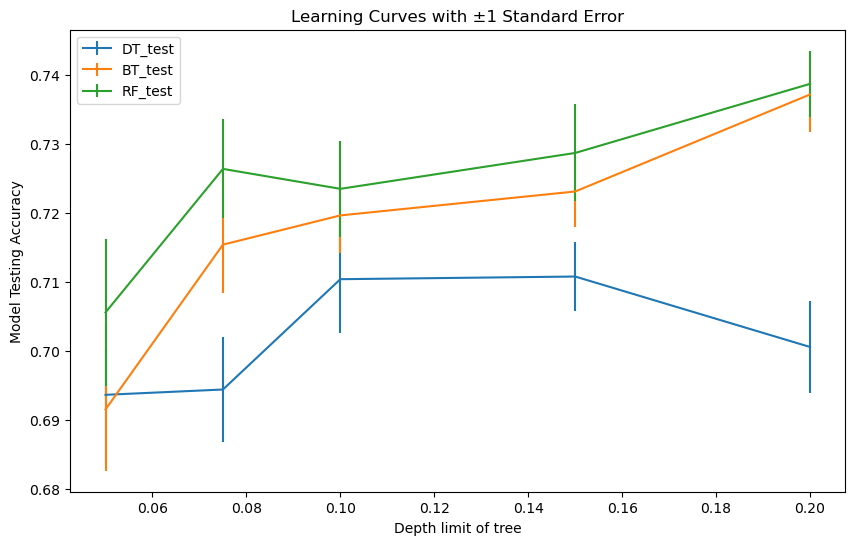

In [29]:
# Plotting
plt.figure(figsize=(10, 6))
plt.errorbar(t_frac_list, q4_mean_test_accu_DT, yerr=q4_stderr_test_accu_DT, label='DT_test')
#plt.errorbar(t_frac_list, q4_mean_train_accu_DT, yerr=q4_stderr_train_accu_DT, label='DT_train')
plt.errorbar(t_frac_list, q4_mean_test_accu_BT, yerr=q4_stderr_test_accu_BT, label='BT_test')
#plt.errorbar(t_frac_list, q4_mean_train_accu_BT, yerr=q4_stderr_train_accu_BT, label='BT_train')
plt.errorbar(t_frac_list, q4_mean_test_accu_RF, yerr=q4_stderr_test_accu_RF, label='RF_test')
#plt.errorbar(t_frac_list, q4_mean_train_accu_RF, yerr=q4_stderr_train_accu_RF, label='RF_train')

plt.xlabel('Depth limit of tree')
plt.ylabel('Model Testing Accuracy')
plt.legend()
plt.title('Learning Curves with ±1 Standard Error')
plt.show()

$H_0$: There is no significant difference in testing accuracy between BT and RF across different sizes of the training set

$H_1$: There is a significant difference in testing accuracy between BT and RF across different sizes of the training set


In [30]:
alpha = 0.05
# Perform a paired t-test
for i, t_frac in enumerate(t_frac_list):
    
    test_accu_BT = q4_results_list_BT[i]
    test_accu_RF = q4_results_list_RF[i]

    t_statistic, p_value = stats.ttest_rel(test_accu_BT, test_accu_RF)


    print(f't_frac = {t_frac} and significance level alpha = {alpha}')

    if p_value < alpha:
        print(f"Reject the null hypothesis with (p-value = {p_value} < alpha)")
    else:
        print(f"Fail to reject the null hypothesis (p-value = {p_value} >= alpha)")

t_frac = 0.05 and significance level alpha = 0.05
Reject the null hypothesis with (p-value = 0.023110043847730008 < alpha)
t_frac = 0.075 and significance level alpha = 0.05
Fail to reject the null hypothesis (p-value = 0.09663370882642082 >= alpha)
t_frac = 0.1 and significance level alpha = 0.05
Fail to reject the null hypothesis (p-value = 0.520194006065847 >= alpha)
t_frac = 0.15 and significance level alpha = 0.05
Fail to reject the null hypothesis (p-value = 0.38173346560949717 >= alpha)
t_frac = 0.2 and significance level alpha = 0.05
Fail to reject the null hypothesis (p-value = 0.7673764414438562 >= alpha)


# Section 5

In [34]:
shuffled_train_df = train_df.sample(frac=1, replace=False, random_state=18)
sampled_shuffled_train_df = shuffled_train_df.sample(frac=0.5, replace=False, random_state=32)


In [35]:
n_samples = len(sampled_shuffled_train_df)

In [36]:
k_folds = 10
n_fold = n_samples*k_folds/100
t = [10, 20, 40, 50]
q5_mean_test_accu_BT = []
q5_stderr_test_accu_BT = []
q5_mean_train_accu_BT = []
q5_stderr_train_accu_BT = []
q5_mean_test_accu_RF = []
q5_stderr_test_accu_RF = []
q5_mean_train_accu_RF = []
q5_stderr_train_accu_RF = []

q5_results_list_BT = []
q5_results_list_RF = []
for n_trees in t:
    print(n_trees)
    test_accu_DT = []
    train_accu_DT = []
    test_accu_BT = []
    train_accu_BT = []
    test_accu_RF = []
    train_accu_RF = []
    for i in range(k_folds):
        # Constructing 
        start = int(i*n_fold)
        end = int((i+1)*n_fold)
        cur_test_df = sampled_shuffled_train_df[start:end]
        cur_train_df = sampled_shuffled_train_df.drop(cur_test_df.index)
        
        # Build a bag of trees
        bag_trees = train_bagging(cur_train_df, n_trees, forest=False, max_depth=8, min_samples=50)
        train_accu_BT.append(accuracy_compute_bagging(bag_trees, cur_train_df))
        test_accu_BT.append(accuracy_compute_bagging(bag_trees, cur_test_df))
        
        # Build a forest
        forests = train_bagging(cur_train_df, n_trees, forest=True, max_depth=8, min_samples=50)
        train_accu_RF.append(accuracy_compute_bagging(forests, cur_train_df))
        test_accu_RF.append(accuracy_compute_bagging(forests, cur_test_df))
    
    q5_mean_test_accu_BT.append(np.mean(test_accu_BT))
    q5_stderr_test_accu_BT.append(np.std(test_accu_BT)/np.sqrt(k_folds))
    q5_mean_train_accu_BT.append(np.mean(train_accu_BT))
    q5_stderr_train_accu_BT.append(np.std(train_accu_BT)/np.sqrt(k_folds))
    
    q5_mean_test_accu_RF.append(np.mean(test_accu_RF))
    q5_stderr_test_accu_RF.append(np.std(test_accu_RF)/np.sqrt(k_folds))
    q5_mean_train_accu_RF.append(np.mean(train_accu_RF))
    q5_stderr_train_accu_RF.append(np.std(train_accu_RF)/np.sqrt(k_folds))

    q5_results_list_BT.append(test_accu_BT)
    q5_results_list_RF.append(test_accu_RF)

10
20
40
50


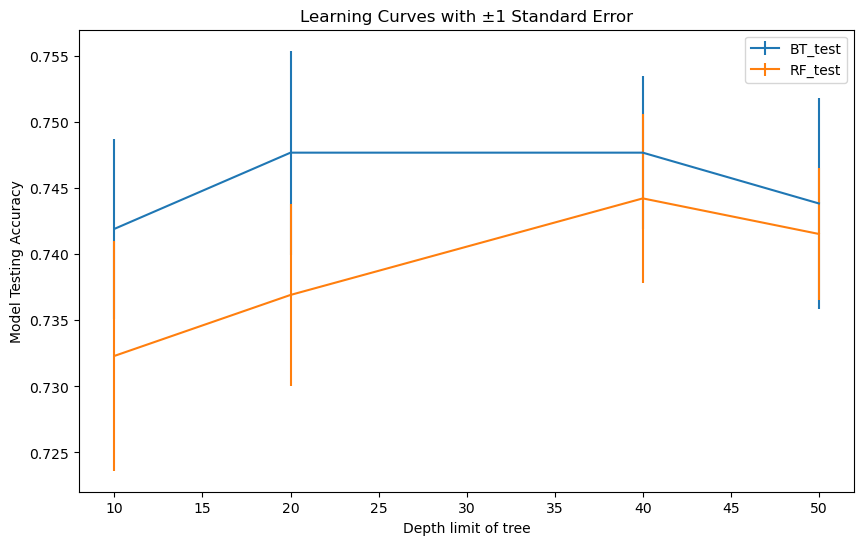

In [37]:
# Plotting
plt.figure(figsize=(10, 6))
plt.errorbar(t, q5_mean_test_accu_BT, yerr=q5_stderr_test_accu_BT, label='BT_test')
#plt.errorbar(t, q5_mean_train_accu_BT, yerr=q5_stderr_train_accu_BT, label='BT_train')
plt.errorbar(t, q5_mean_test_accu_RF, yerr=q5_stderr_test_accu_RF, label='RF_test')
#plt.errorbar(t, q5_mean_train_accu_RF, yerr=q5_stderr_train_accu_RF, label='RF_train')

plt.xlabel('Depth limit of tree')
plt.ylabel('Model Testing Accuracy')
plt.legend()
plt.title('Learning Curves with ±1 Standard Error')
plt.show()

$H_0$: There is no significant difference in testing accuracy between BT and RF across different number of trees building

$H_1$: There is a significant difference in testing accuracy between BT and RF across different number of trees building


In [38]:
alpha = 0.05
# Perform a paired t-test
for i, n_trees in enumerate(t):
    
    test_accu_BT = q5_results_list_BT[i]
    test_accu_RF = q5_results_list_RF[i]

    t_statistic, p_value = stats.ttest_rel(test_accu_BT, test_accu_RF)


    print(f't_frac = {t_frac} and significance level alpha = {alpha}')

    if p_value < alpha:
        print(f"Reject the null hypothesis with (p-value = {p_value} < alpha)")
    else:
        print(f"Fail to reject the null hypothesis (p-value = {p_value} >= alpha)")

t_frac = 0.2 and significance level alpha = 0.05
Fail to reject the null hypothesis (p-value = 0.24312668581445357 >= alpha)
t_frac = 0.2 and significance level alpha = 0.05
Reject the null hypothesis with (p-value = 0.04847307211748701 < alpha)
t_frac = 0.2 and significance level alpha = 0.05
Fail to reject the null hypothesis (p-value = 0.34963753821244825 >= alpha)
t_frac = 0.2 and significance level alpha = 0.05
Fail to reject the null hypothesis (p-value = 0.7252581045657733 >= alpha)


# Bonus: Neural Network

In [62]:
def sigmoid_function(x):
    return 1 / (1 + np.exp(-x))

# Define the derivative of the sigmoid function
def sigmoid_derivative(x):
    return x * (1 - x)


In [63]:
# Define the neural network class
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, lr):
        # Initialize the weights and biases
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        self.w = np.random.randn(self.input_size, self.output_size)
        self.b = np.zeros((1, self.output_size))

        
        self.lr = lr

    def forward(self, x):
        # Perform the feedforward pass
        #x = np.dot(x, self.w1)+self.b1
        #x = sigmoid_function(x)
        
        #self.output1 = x 
        
        self.y_pred = sigmoid_function(x@self.w + self.b)

        return self.y_pred

    def backprop(self, x, targets):
        # Calculate the loss
        loss = self.y_pred-targets

        # Compute the grads
        output_delta = loss * sigmoid_derivative(self.y_pred)

        # Update the w's
        self.w = self.w - self.lr*((x.T@output_delta).reshape(self.w.shape))
        self.b = self.b - self.lr*np.sum(output_delta, axis=0, keepdims=True)
    

    def train(self, X, y, max_epoch):
        for epoch in range(max_epoch):
            for x_i, y_i in zip(X, y):
                x_i = x_i[np.newaxis,:]
                y_pred = self.forward(x_i)
                self.backprop(x_i, y_i)

    def predict(self, x):
        return x@self.w + self.b

In [64]:
def accuracy_nn(X, y, nn):
    y_pred  = np.array([1 if sigmoid_function(value) > 0.5 else 0 for value in nn.predict(X)])  
    cnt = (y_pred==y).sum()
    return cnt/len(y)

In [65]:
n_samples = len(sampled_shuffled_train_df)

In [66]:
n = len(train_df)
idx_list = list(train_df.index)
X = train_df.values
y = np.array(train_df['decision'])
X_test = test_df.values
y_test = np.array(test_df['decision'])


In [67]:
# Tunning hyper-parameters: learning rate, hidden_size and epochs by grid-search
lr_list = [0.01, 0.02, 0.03, 0.05]
epochs_list = [10, 20, 30]
hidden_size_list = [10, 20, 32]
best_accu = 0
best_combo = []
for lr in lr_list:
    for epochs in epochs_list:
        for hidden_size in hidden_size_list:
            print(f'---lr={lr} & max_epoch = {epochs} & hidden_size = {hidden_size} ---', flush=True)
            # Create and train the neural network
            nn = NeuralNetwork(input_size=X.shape[1], hidden_size=hidden_size, output_size=1, lr=lr)
            nn.train(X, y, max_epoch=epochs)
            test_accu = accuracy_nn(X_test, y_test, nn)
            print(f'Training Accuracy = {accuracy_nn(X, y, nn)}', flush=True)
            print(f'Testing Accuracy = {test_accu}', flush=True)
            
            if test_accu >= best_accu:
                best_accu = test_accu
                best_combo = [lr, epochs, hidden_size]

print(f'Best combo: lr={best_combo[0]} & max_epoch = {best_combo[1]} & hidden_size = {best_combo[2]}', flush=True)

---lr=0.01 & max_epoch = 10 & hidden_size = 10 ---
Training Accuracy = 0.9988461538461538
Testing Accuracy = 0.9984615384615385
---lr=0.01 & max_epoch = 10 & hidden_size = 20 ---
Training Accuracy = 0.9986538461538461
Testing Accuracy = 0.9992307692307693
---lr=0.01 & max_epoch = 10 & hidden_size = 32 ---
Training Accuracy = 0.995576923076923
Testing Accuracy = 0.9961538461538462
---lr=0.01 & max_epoch = 20 & hidden_size = 10 ---
Training Accuracy = 0.9998076923076923
Testing Accuracy = 1.0
---lr=0.01 & max_epoch = 20 & hidden_size = 20 ---
Training Accuracy = 0.9992307692307693
Testing Accuracy = 1.0
---lr=0.01 & max_epoch = 20 & hidden_size = 32 ---
Training Accuracy = 1.0
Testing Accuracy = 1.0
---lr=0.01 & max_epoch = 30 & hidden_size = 10 ---
Training Accuracy = 1.0
Testing Accuracy = 1.0
---lr=0.01 & max_epoch = 30 & hidden_size = 20 ---
Training Accuracy = 1.0
Testing Accuracy = 1.0
---lr=0.01 & max_epoch = 30 & hidden_size = 32 ---
Training Accuracy = 1.0
Testing Accuracy = 1.0

We employed the grid search strategy to fine-tune the critical hyper-parameters. We traversed a range of learning rates—0.01, 0.02, 0.03, and 0.05—played around with epochs spanning from 10 to 30, and tinkered with hidden layer sizes of 10, 20, and 32. Amid this search, the best combo emerged through the grid search: lr=0.05, max_epoch=30, and hidden_size=32, with the training accuracy and testing accuracy shown below:

In [70]:
nn = NeuralNetwork(input_size=X.shape[1], hidden_size=best_combo[2], output_size=1, lr=best_combo[0])
nn.train(X, y, max_epoch=best_combo[1])
test_accu = accuracy_nn(X_test, y_test, nn)
print(f'Training Accuracy = {accuracy_nn(X, y, nn)}', flush=True)
print(f'Testing Accuracy = {test_accu}', flush=True)

Training Accuracy = 1.0
Testing Accuracy = 1.0
